In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
df.head()

,Area,Item,Element,Year,Unit,Value
0,Afghanistan,Asses,Stocks,1961,Head,1300000.0
1,Afghanistan,Asses,Stocks,1962,Head,851850.0
2,Afghanistan,Asses,Stocks,1963,Head,1001112.0
3,Afghanistan,Asses,Stocks,1964,Head,1150000.0
4,Afghanistan,Asses,Stocks,1965,Head,1300000.0


In [ ]:



df.tail()

,Area,Item,Element,Year,Unit,Value
23591,Cyprus,Chickens,Stocks,2008,1000 Head,2904.0
23592,Cyprus,Chickens,Stocks,2009,1000 Head,2960.0
23593,Cyprus,Chickens,Stocks,2010,1000 Head,2981.0
23594,Cyprus,Chickens,Stocks,2011,1000 Head,2890.0
23595,Cyprus,Chickens,Stocks,2012,1000 Hea,NaN



# Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23596 entries, 0 to 23595
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Area     23596 non-null  object 
 1   Item     23596 non-null  object 
 2   Element  23596 non-null  object 
 3   Year     23596 non-null  int64  
 4   Unit     23596 non-null  object 
 5   Value    23222 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 1.1+ MB


In [ ]:
df = df.drop(['Element', 'Unit'], axis=1)


In [ ]:
df.head()

,Area,Item,Year,Value
0,Afghanistan,Asses,1961,1300000.0
1,Afghanistan,Asses,1962,851850.0
2,Afghanistan,Asses,1963,1001112.0
3,Afghanistan,Asses,1964,1150000.0
4,Afghanistan,Asses,1965,1300000.0


In [ ]:
print(df.isnull().sum())


Area       0
Item       0
Year       0
Value    374
dtype: int64


In [ ]:
df.head()

,Area,Item,Year,Value
0,Afghanistan,Asses,1961,1300000.0
1,Afghanistan,Asses,1962,851850.0
2,Afghanistan,Asses,1963,1001112.0
3,Afghanistan,Asses,1964,1150000.0
4,Afghanistan,Asses,1965,1300000.0


In [ ]:
df = df.dropna()


In [ ]:
df.head()

,Area,Item,Year,Value
0,Afghanistan,Asses,1961,1300000.0
1,Afghanistan,Asses,1962,851850.0
2,Afghanistan,Asses,1963,1001112.0
3,Afghanistan,Asses,1964,1150000.0
4,Afghanistan,Asses,1965,1300000.0


# Encoding + Scaling

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
le_area = LabelEncoder()
le_item = LabelEncoder()

In [ ]:
df['Area_encoded'] = le_area.fit_transform(df['Area'])
df['Item_encoded'] = le_item.fit_transform(df['Item'])

In [ ]:
features = ['Year', 'Area_encoded', 'Item_encoded']
target = 'Value'

In [ ]:
X = df[features]
y = df[target]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
print("Features shape:", X_scaled.shape)
print("Target shape:", y.shape)

Features shape: (23596, 3)
Target shape: (23596,)


# outliers

In [ ]:
Q1 = df['Value'].quantile(0.25)
Q3 = df['Value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Value'] < lower_bound) | (df['Value'] > upper_bound)]
print("Number of Outliers:", outliers.shape[0])

Number of Outliers: 3665


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21911 entries, 3 to 22538
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Area          21911 non-null  object 
 1   Item          21911 non-null  object 
 2   Element       21911 non-null  object 
 3   Year          21911 non-null  int64  
 4   Unit          21911 non-null  object 
 5   Value         21911 non-null  float64
 6   Area_encoded  21911 non-null  int64  
 7   Item_encoded  21911 non-null  int64  
 8   lag1          21911 non-null  float64
 9   lag2          21911 non-null  float64
 10  lag3          21911 non-null  float64
dtypes: float64(4), int64(3), object(4)
memory usage: 2.0+ MB


# Feature Engineering

In [ ]:
df = df.sort_values(['Area', 'Item', 'Year'])

df['lag1'] = df.groupby(['Area', 'Item'])['Value'].shift(1)
df['lag2'] = df.groupby(['Area', 'Item'])['Value'].shift(2)
df['lag3'] = df.groupby(['Area', 'Item'])['Value'].shift(3)
df = df.dropna()
print(df.head())

           Area   Item Element  Year  Unit      Value  Area_encoded  \
6   Afghanistan  Asses  Stocks  1967  Head  1200000.0             0   
7   Afghanistan  Asses  Stocks  1968  Head  1328000.0             0   
8   Afghanistan  Asses  Stocks  1969  Head  1250000.0             0   
9   Afghanistan  Asses  Stocks  1970  Head  1300000.0             0   
10  Afghanistan  Asses  Stocks  1971  Head  1300000.0             0   

    Item_encoded       lag1       lag2       lag3  
6              0  1200000.0  1300000.0  1150000.0  
7              0  1200000.0  1200000.0  1300000.0  
8              0  1328000.0  1200000.0  1200000.0  
9              0  1250000.0  1328000.0  1200000.0  
10             0  1300000.0  1250000.0  1328000.0  


# Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (18876, 3)
Testing Data Shape: (4720, 3)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23596 entries, 0 to 23595
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Area          23596 non-null  object 
 1   Item          23596 non-null  object 
 2   Element       23596 non-null  object 
 3   Year          23596 non-null  int64  
 4   Unit          23596 non-null  object 
 5   Value         23222 non-null  float64
 6   Area_encoded  23596 non-null  int64  
 7   Item_encoded  23596 non-null  int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 1.4+ MB


# Feature Engineering

In [ ]:
df = df.sort_values(['Area', 'Item', 'Year'])

df['lag1'] = df.groupby(['Area', 'Item'])['Value'].shift(1)
df['lag2'] = df.groupby(['Area', 'Item'])['Value'].shift(2)
df['lag3'] = df.groupby(['Area', 'Item'])['Value'].shift(3)
df = df.dropna()
print(df.head())

          Area   Item Element  Year  Unit      Value  Area_encoded  \
3  Afghanistan  Asses  Stocks  1964  Head  1150000.0             0   
4  Afghanistan  Asses  Stocks  1965  Head  1300000.0             0   
5  Afghanistan  Asses  Stocks  1966  Head  1200000.0             0   
6  Afghanistan  Asses  Stocks  1967  Head  1200000.0             0   
7  Afghanistan  Asses  Stocks  1968  Head  1328000.0             0   

   Item_encoded       lag1       lag2       lag3  
3             0  1001112.0   851850.0  1300000.0  
4             0  1150000.0  1001112.0   851850.0  
5             0  1300000.0  1150000.0  1001112.0  
6             0  1200000.0  1300000.0  1150000.0  
7             0  1200000.0  1200000.0  1300000.0  


In [ ]:
X = df[["lag1", "lag2", "lag3"]]
y = df["Value"]

# Train Split Data

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Model

In [ ]:
#polynomial regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=3)  

X_poly = poly.fit_transform(X_train)

model = LinearRegression()
model.fit(X_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
from sklearn.metrics import r2_score
X_test_poly = poly.transform(X_test)

y_pred = model.predict(X_test_poly)

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9367468027227006


In [ ]:
#Linear regression
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score
print("Test R2:", r2_score(y_test, y_pred))

Test R2: 0.9367468027227006


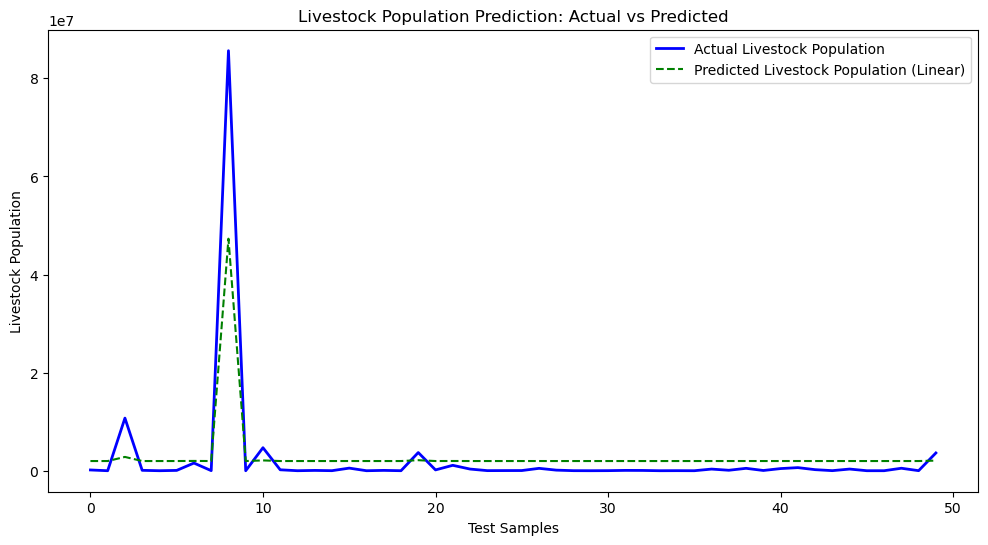

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values[:50], label='Actual Livestock Population', color='blue', linewidth=2)
plt.plot(y_pred[:50], label='Predicted Livestock Population (Linear)', color='green', linestyle='--')
plt.title('Livestock Population Prediction: Actual vs Predicted')
plt.xlabel('Test Samples')
plt.ylabel('Livestock Population')
plt.legend()
plt.show()

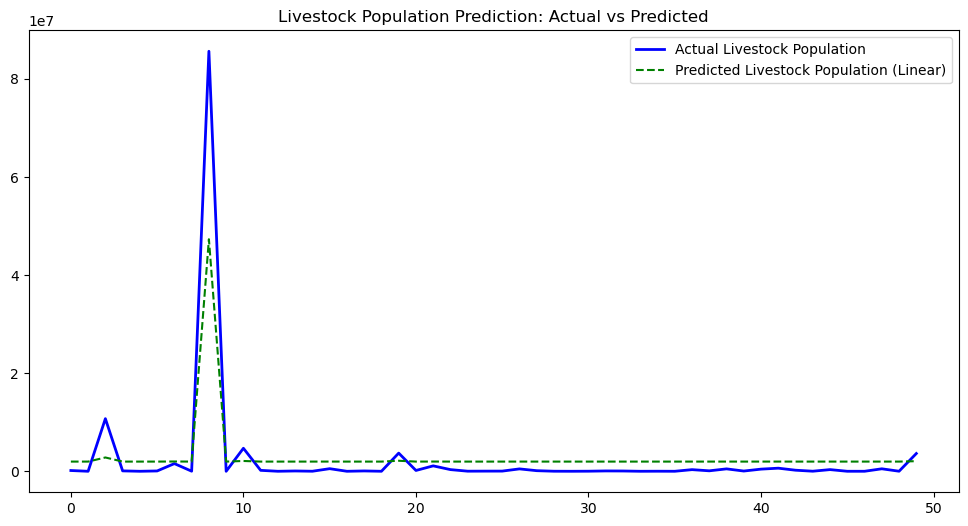

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values[:50], label='Actual Livestock Population', color='blue', linewidth=2)
plt.plot(y_pred[:50], label='Predicted Livestock Population (Linear)', color='green', linestyle='--')
plt.title('Livestock Population Prediction: Actual vs Predicted')
plt.legend()
plt.show()

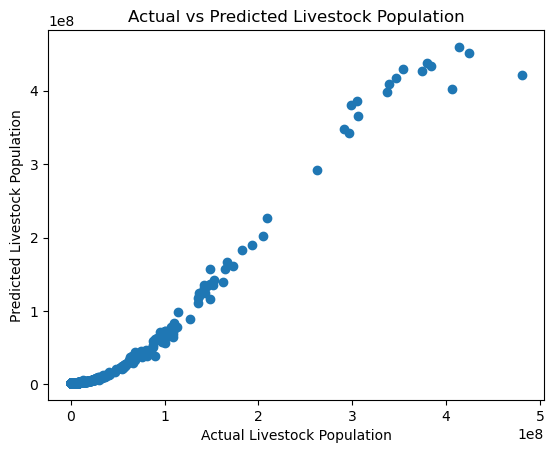

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Livestock Population")
plt.ylabel("Predicted Livestock Population")
plt.title("Actual vs Predicted Livestock Population")
plt.show()

In [ ]:
future_data = np.array([[32000000, 31500000, 31000000]])
future_data_poly = poly.transform(future_data)
prediction = model.predict(future_data_poly)
print(f"Predicted Livestock Population: {prediction[0]:.2f}")

Predicted Livestock Population: 9678071.79


c:\Users\ashis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [8]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
])
print("Required libraries installed successfully.")


Required libraries installed successfully.


In [18]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



TRAINING MODEL

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

RANDOM FOREST AND HYPER PARAMETER


In [20]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)


print("========== RANDOM FOREST ==========")
print("R2 Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("MSE      :", mean_squared_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

========== RANDOM FOREST ==========
R2 Score : 0.9680785630055987
MAE      : 433.7142857142857
MSE      : 200649.81428571444
RMSE     : 447.9395207901558


In [21]:
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

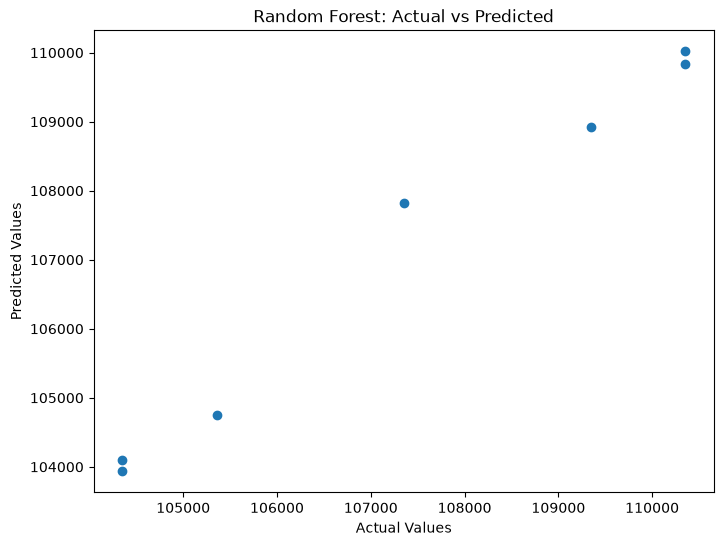

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

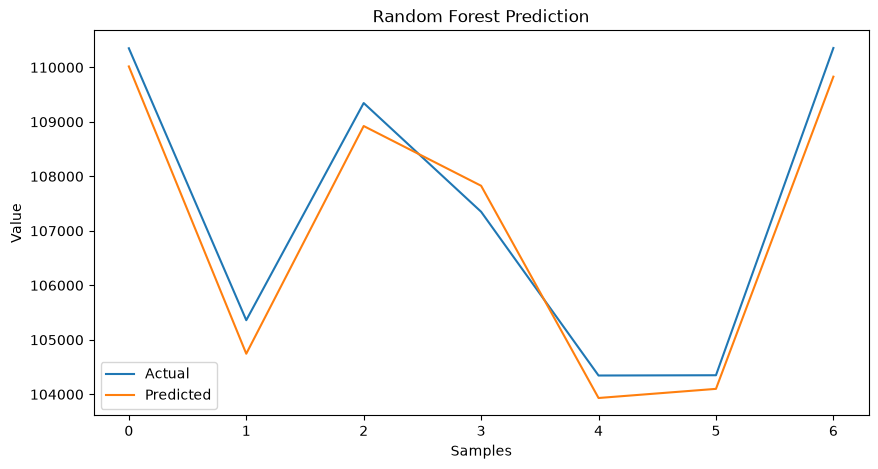

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual")
plt.plot(rf_pred[:50], label="Predicted")
plt.title("Random Forest Prediction")
plt.xlabel("Samples")
plt.ylabel("Value")
plt.legend()
plt.show()

In [25]:
import pickle

# Save Random Forest model
with open("model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Random Forest model saved successfully as model.pkl")

Random Forest model saved successfully as model.pkl


random forest


In [26]:
from sklearn.ensemble import RandomForestRegressor
import pickle

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

with open("model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!
